In [1]:
import pandas as pd
import numpy as np

# List of GitHub raw URLs for the CSV files
github_links = [
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2014_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2015_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2016_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2017_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2018_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2019_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2020_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2021_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2022_World2500.csv",
    "https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/SB2023_World2500.csv"
]

# List to store DataFrames
dataframes = []

# Load each file into a separate DataFrame
for file in github_links:
    df = pd.read_csv(file)
    dataframes.append(df)

nan_value = float("NaN")

worldFUAs = pd.read_csv('https://raw.githubusercontent.com/veghmark12/r_d_investments/refs/heads/main/world_FUAs2.csv')

In [2]:
# List of words to check in column names
words_to_remove = ["Unnamed", "Market", "Employees","Profits","Profitability","Capex","Sales","Op.profits","Op.","sales","growth","intensity","rank","Rank","Year"]

# Remove columns containing any of the words from the list
for i, df in enumerate(dataframes):
    columns_to_drop = [col for col in df.columns if any(word in col for word in words_to_remove)]
    df.drop(columns=columns_to_drop, inplace=True, errors='ignore')  # errors='ignore' in case no columns match

In [3]:
years  = []
startyear = 2013

for i in range(10):
    year = startyear + i
    years.append(year)

for i, df in enumerate(dataframes):
    a = years[i]
    df['Year'] = f'{a}'

In [4]:
new_first_column_name = "Company"

for i, df in enumerate(dataframes):
    first_column = df.columns[0]
    df.rename(columns={first_column: new_first_column_name}, inplace=True)

In [5]:
# Value to rename and the new value
old_value = "The Netherlands"
new_value = "Netherlands"

# Rename the value across all DataFrames
for i, df in enumerate(dataframes):
    dataframes[i] = df.replace(to_replace=old_value, value=new_value)

In [6]:
# Column name to check
column_name = "Country"

# Collect all unique values from the specified column across all DataFrames
all_values = []
for df in dataframes:
    if column_name in df.columns:
        all_values.extend(df[column_name].dropna().unique())  # Drop NaN values and get unique values

# Print out all unique values
unique_values = pd.Series(all_values).unique()

In [7]:
# Define country groups
eu_countries = ["Austria", "Belgium", "Bulgaria", "Croatia", "Cyprus", "Czech Republic",
    "Denmark", "Estonia", "Finland", "France", "Germany", "Greece", "Hungary",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Netherlands", "Poland", "Portugal", "Romania", "Slovakia", "Slovenia",
    "Spain", "Sweden"]  # Add all EU countries
us_countries = ["US"]
china_countries = ["China"]
row_countries = []  # RoW countries will be inferred later

# Add a "region" column to each DataFrame
for i, df in enumerate(dataframes):
    def get_region(country):
        if country in eu_countries:
            return "EU"
        elif country in us_countries:
            return "US"
        elif country in china_countries:
            return "China"
        else:
            return "RoW"  # Rest of the World

    # Apply the function to assign regions
    df["Region"] = df["Country"].apply(get_region)

In [8]:
# Column to rename and its new name
old_column_name = "Industrial sector (ICB-3D)"
new_column_name = "Industry"

# Rename the column in each DataFrame
for i, df in enumerate(dataframes):
    if old_column_name in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={old_column_name: new_column_name}, inplace=True)

In [9]:
# Column to rename and its new name
old_column_name = "Industry-ICB3 sector name"
new_column_name = "Industry"

# Rename the column in each DataFrame
for i, df in enumerate(dataframes):
    if old_column_name in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={old_column_name: new_column_name}, inplace=True)

In [10]:
# Specify the column names to be renamed in each DataFrame
column_names_to_rename = [
    " R&D 2013 (€million)",  # Column to rename in df1
    " R&D 2014 (€million)",  # Column to rename in df2
    " R&D 2015/16 (€million)",
    "R&D 2016/17 (€million)",
    "R&D 2017/18 (€mn)",
    "R&D 2018/19 (€million)",
    "R&D 2019 (€million)",
    "R&D 2020 (€million)",
    "R&D 2021 (€million)",
    "R&D (€ million)"
]

# Loop through each DataFrame and rename the corresponding column
for i, df in enumerate(dataframes):
    column_to_rename = column_names_to_rename[i]  # Get the column name to rename
    if column_to_rename in df.columns:  # Check if the column exists in the DataFrame
        df.rename(columns={column_to_rename: "R&D (€ million)"}, inplace=True)
    else:
        print(f"Column '{column_to_rename}' not found in DataFrame {i+1}")

In [11]:
# Remove commas and convert to float
for df in dataframes:
    df['R&D (€ million)'] = df['R&D (€ million)'].replace({',': ''}, regex=True)

In [12]:
for df in dataframes:
    df['R&D (€ million)'] = df['R&D (€ million)'].replace('', None)  # Replace empty strings with None (optional)
    df['R&D (€ million)'] = pd.to_numeric(df['R&D (€ million)'], errors='coerce')  # Convert to float, invalid values become NaN

In [13]:
#for df in dataframes:
#    df.replace(["China","US","RoW"], nan_value, inplace=True)
#    df.dropna(subset = ['Region'],inplace = True, axis=0)

In [14]:
# Value to rename and the new value
old_value = "Gas, Water & Multi-utilities"
new_value = "Gas, Water & Multiutilities"

# Rename the value across all DataFrames
for i, df in enumerate(dataframes):
    dataframes[i] = df.replace(to_replace=old_value, value=new_value)

In [15]:
# Column name to check
column_name = "Company"

# Collect all unique values from the specified column across all DataFrames
all_values = []
for df in dataframes:
    if column_name in df.columns:
        all_values.extend(df[column_name].dropna().unique())  # Drop NaN values and get unique values

# Print out all unique values
unique_values = pd.Series(all_values).unique()

In [16]:
values_to_keep = ["Electricity","Gas, Water & Multiutilities","Alternative Energy"]

for i, df in enumerate(dataframes):  # Loop through each DataFrame in the list
    dataframes[i] = df[df['Industry'].isin(values_to_keep)]  # Filter rows where 'Industry' is in values_to_keep

In [17]:
totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    total = df['R&D (€ million)'].sum()
    totals.append(total)

eu_totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    df = df[df['Region'] == 'EU']
    total = df['R&D (€ million)'].sum()
    eu_totals.append(total)

us_totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    df = df[df['Region'] == 'US']
    total = df['R&D (€ million)'].sum()
    us_totals.append(total)

china_totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    df = df[df['Region'] == 'China']
    total = df['R&D (€ million)'].sum()
    china_totals.append(total)

RoW_totals = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    df = df[df['Region'].isin(['RoW', 'Japan'])]
    total = df['R&D (€ million)'].sum()
    RoW_totals.append(total)

percentage_EU = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    percentage_EU.append((eu_totals[i] / totals[i]) * 100)

percentage_US = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    percentage_US.append((us_totals[i] / totals[i]) * 100)

percentage_China = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    percentage_China.append((china_totals[i] / totals[i]) * 100)

percentage_RoW = []
for i, df in enumerate(dataframes):
    df = dataframes[i]
    percentage_RoW.append((RoW_totals[i] / totals[i]) * 100)

In [18]:
# prompt: make a df which contains for each region and each year the total sum of investments from that region

import pandas as pd
# Create a dictionary to store the data
data = {
    'Year': years,
    'EU': eu_totals,
    'US': us_totals,
    'China': china_totals,
    'RoW': RoW_totals
}

# Create the DataFrame
investments_by_region = pd.DataFrame(data)

# Display the DataFrame
investments_by_region


,Year,EU,US,China,RoW
0,2013,2795.800000,233.700000,36.500000,1492.000000
1,2014,2640.300000,297.400000,205.200000,1292.800000
2,2015,2303.100000,431.000000,612.000000,1482.200000
3,2016,2224.900000,308.200000,634.500000,1771.800000
4,2017,2499.600000,325.700000,462.200000,1844.700000
5,2018,2520.100000,308.900000,712.700000,1851.300000
6,2019,2919.400000,363.300000,867.300000,1909.800000
7,2020,4068.576574,361.715644,894.711499,1707.901901
8,2021,4364.521101,669.191936,1599.791954,1571.612907
9,2022,4616.868923,865.171005,1890.482170,1441.436294


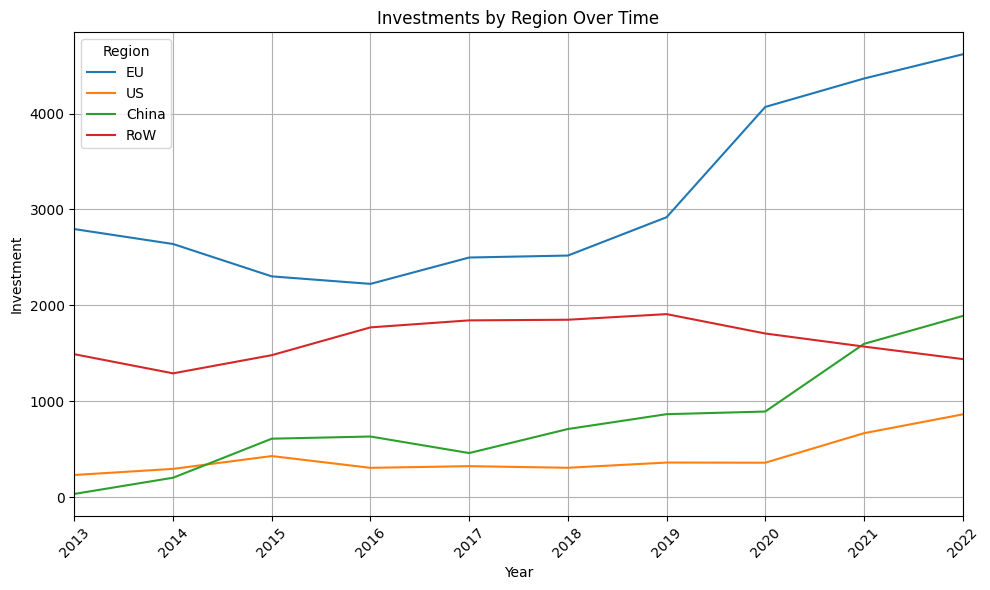

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Reshape the dataframe from wide to long format
investments_long = pd.melt(investments_by_region, id_vars=['Year'], var_name='Region', value_name='Investment')

# Create the plot
plt.figure(figsize=(10, 6))

# Plot each region's line
for region in investments_long['Region'].unique():
    data = investments_long[investments_long['Region'] == region]
    plt.plot(data['Year'], data['Investment'], label=region)

# Show every year on x-axis
years = sorted(investments_long['Year'].unique())
plt.xticks(years, rotation=45)

# Set x-axis limits to avoid padding
plt.xlim(min(years), max(years))

# Final touches
plt.title('Investments by Region Over Time')
plt.xlabel('Year')
plt.ylabel('Investment')
plt.legend(title='Region')
plt.grid(True)
plt.tight_layout()
plt.show()


In [20]:
investments_long

,Year,Region,Investment
0,2013,EU,2795.800000
1,2014,EU,2640.300000
2,2015,EU,2303.100000
3,2016,EU,2224.900000
4,2017,EU,2499.600000
5,2018,EU,2520.100000
6,2019,EU,2919.400000
7,2020,EU,4068.576574
8,2021,EU,4364.521101
9,2022,EU,4616.868923


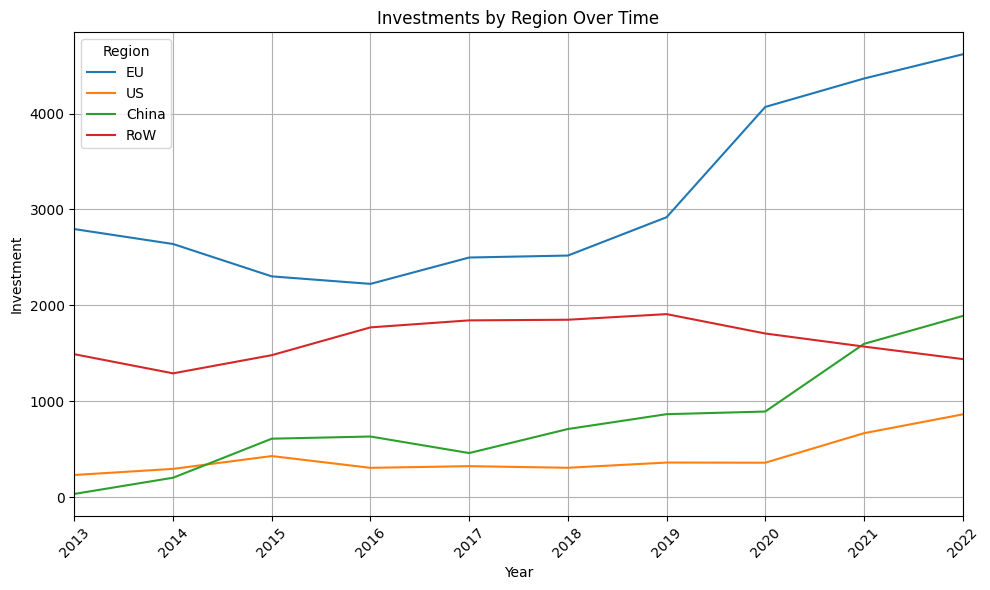

In [21]:
# prompt: show the change of top investor countries from the EU over the years

# Assuming the previous code is executed and the 'investments_by_region' DataFrame is available

import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))

# Plot each region's line
for region in ['EU', 'US', 'China', 'RoW']:
    plt.plot(investments_by_region['Year'], investments_by_region[region], label=region)

# Show every year on x-axis
plt.xticks(investments_by_region['Year'], rotation=45)

# Set x-axis limits to avoid padding
plt.xlim(min(investments_by_region['Year']), max(investments_by_region['Year']))


# Final touches
plt.title('Investments by Region Over Time')
plt.xlabel('Year')
plt.ylabel('Investment')
plt.legend(title='Region')
plt.grid(True)
plt.tight_layout()
plt.show()


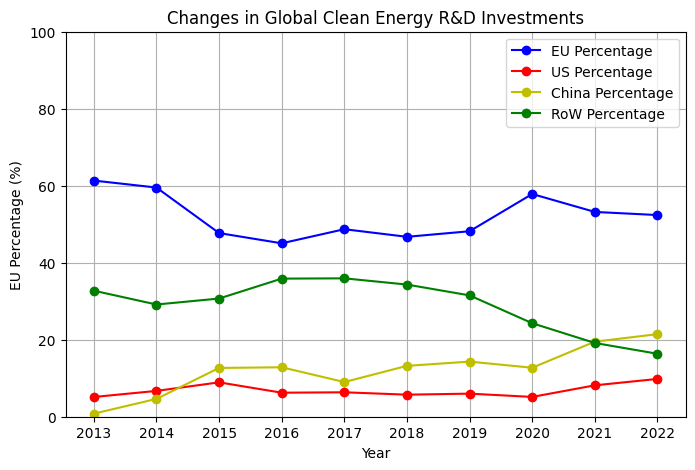

In [22]:
import matplotlib.pyplot as plt

# Plot the percentage of EU investments over the years
plt.figure(figsize=(8, 5))
plt.plot(years, percentage_EU, marker='o', color='b', label='EU Percentage')
plt.plot(years, percentage_US, marker='o', color='r', label='US Percentage')
plt.plot(years, percentage_China, marker='o', color='y', label='China Percentage')
plt.plot(years, percentage_RoW, marker='o', color='g', label='RoW Percentage')
# Add labels and title
plt.title('Changes in Global Clean Energy R&D Investments')
plt.xlabel('Year')
plt.ylabel('EU Percentage (%)')
plt.grid(True)
plt.ylim(0, 100)
plt.xticks(years)

# Show the plot
plt.legend()
plt.show()


In [23]:
!pip install pandas opencage

In [ ]:
import pandas as pd
from opencage.geocoder import OpenCageGeocode
import time

# Your OpenCage API key
API_KEY = '1f565f92418545f6ac65946f084e25b9'
geocoder = OpenCageGeocode(API_KEY)

# Function to get coordinates for a given location
def get_coordinates(company_name):
    try:
        result = geocoder.geocode(company_name)
        if result and len(result) > 0:
            lat = result[0]['geometry']['lat']
            lng = result[0]['geometry']['lng']
            return lat, lng
        else:
            return None, None
    except Exception as e:
        print(f"Error fetching coordinates for {company_name}: {e}")
        return None, None

# Process each DataFrame
updated_dataframes = []
for idx, df in enumerate(dataframes):
    print(f"Processing DataFrame {idx + 1}")
    df['Latitude'] = None
    df['Longitude'] = None

    for i, row in df.iterrows():
        company_name = row['Company']
        lat, lng = get_coordinates(company_name)
        df.at[i, 'Latitude'] = lat
        df.at[i, 'Longitude'] = lng

    updated_dataframes.append(df)

# Combine all updated DataFrames if needed
final_df = pd.concat(updated_dataframes, ignore_index=True)

# Display the final DataFrame
print(final_df)

Processing DataFrame 1
Error fetching coordinates for ELECTRICITE DE FRANCE: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for KOREA ELECTRIC POWER: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for AREVA: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for RWE: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for VESTAS WIND SYSTEMS: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for SCOTTISH AND SOUTHERN ENERGY: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for GDF SUEZ: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for IBERDROLA: Your API key is not authorized. You may have entered it incorrectly.
Error fetching coordinates for VEOLIA ENVIRONNEM

In [ ]:
final_df.loc[final_df['Company'].str.contains('E.ON', case=False, na=False), ['Latitude', 'Longitude']] = [51.450832, 7.013056]
final_df.loc[final_df['Company'].str.contains('ENEL', case=False, na=False), ['Latitude', 'Longitude']] = [41.902782, 12.496366]
final_df.loc[final_df['Company'].str.contains('TEOLLISUUDEN VOIMA', case=False, na=False), ['Latitude', 'Longitude']] = [61.2, 21.73333]

In [ ]:
output_file = 'r&d_last10years_investments.csv'
final_df.to_csv(output_file, index=False)

In [ ]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# Load your data
fuas_file = 'world_FUAs.csv'  # Replace with the FUAs file
final_file = 'r&d_last10years_investments.csv'  # Replace with your cities file

fuas_df = pd.read_csv(fuas_file)  # FUAs with coordinates
final_df2 = pd.read_csv(final_file)  # Cities with coordinates

# Haversine formula to calculate the great-circle distance between two points
def haversine(lat1, lon1, lat2, lon2):
    # Check if any of the coordinates are None and return a large distance if so
    if any(x is None for x in [lat1, lon1, lat2, lon2]):
        return float('inf')  # Return infinity if any coordinate is None
    R = 6371  # Earth radius in kilometers
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Find the closest FUA for each city within the same country
def find_closest_fua(city_lat, city_lon, city_country, fua_data):
    # Filter FUAs by the country of the city
    filtered_fuas = fua_data[fua_data['COUNTRY'] == city_country]

    # If no FUAs found for the country, return None
    if filtered_fuas.empty:
        return None

    min_distance = float('inf')
    closest_fua = None
    for _, fua_row in filtered_fuas.iterrows():
        fua_lat = fua_row['Latitude']
        fua_lon = fua_row['Longitude']
        distance = haversine(city_lat, city_lon, fua_lat, fua_lon)
        if distance < min_distance:
            min_distance = distance
            closest_fua = fua_row['FUA']

    return closest_fua

# Apply the function to find the closest FUA for each city
final_df2['Closest FUA'] = final_df2.dropna(subset=['Latitude', 'Longitude', 'Country']).apply(
    lambda row: find_closest_fua(row['Latitude'], row['Longitude'], row['Country'], fuas_df), axis=1
)

# Save the updated dataframe to a new file
output_file = 'r&d_last10years_investments_FUAs.csv'
final_df2.to_csv(output_file, index=False)
final_df2

FileNotFoundError: [Errno 2] No such file or directory: 'world_FUAs.csv'

In [ ]:
final_df2.rename(columns={'Closest FUA': 'FUA'}, inplace=True)
final_df2

# Merge df1 with df2 on the 'City' column to add coordinates
df_merged = final_df2.merge(worldFUAs, on='FUA', how='left')
df_filtered = df_merged[df_merged['Region'].str.contains('EU', na=False)]

# Display the resulting DataFrame
df_filtered

In [ ]:
output_file = 'df_filtered.csv'
df_filtered.to_csv(output_file, index=False)

In [ ]:
import pandas as pd
import folium
import os
from folium.plugins import TimestampedGeoJson

# Normalize R&D for circle size scaling
df_filtered['R&D_scaled'] = df_filtered['R&D (€ million)'] / df_filtered['R&D (€ million)'].max() * 30  # Adjust scale for better visibility

# Prepare features for TimestampedGeoJson
features = []
for _, row in df_filtered.iterrows():
    feature = {
        'type': 'Feature',
        'geometry': {
            'type': 'Point',
            'coordinates': [row['Longitude_y'], row['Latitude_y']]
        },
        'properties': {
            'time': f"{row['Year']}-01-01T00:00:00Z",  # Use start of the year
            'popup': f"Company: {row['Company']}<br>R&D: {row['R&D (€ million)']} € million<br>Year: {row['Year']}",
            'icon': 'circle',
            'iconstyle': {
                'color': 'red',
                'fillColor': 'red',
                'fillOpacity': 0.6,
                'radius': row['R&D_scaled']
            }
        }
    }
    features.append(feature)

# Create Folium map
m = folium.Map(location=[47.39005, 0.688927], zoom_start=6)

# Add timestamped layer
timestamped_geojson = TimestampedGeoJson(
    {'type': 'FeatureCollection', 'features': features},
    period='P1Y',  # 1-year intervals
    add_last_point=True,
    duration='P1Y'
)
timestamped_geojson.add_to(m)

# Save map to HTML
m.save("rd_map_timelapse.html")

# Open the map if running locally (optional)
print("Map timelapse created! Open 'rd_map_timelapse.html' to view it.")


In [ ]:
!apt update
!apt install -y chromium-chromedriver
!pip install selenium

In [ ]:
from PIL import Image

def crop_image(image_path, crop_box):
    with Image.open(image_path) as img:
        cropped_img = img.crop(crop_box)
        cropped_img.save("cropped_" + image_path)

crop_box = (240, 156, 1408, 956)  # define your crop area coordinates

image_paths = ['1.png', '2.png', '3.png', '4.png', '5.png', '6.png', '7.png', '8.png', '9.png', '10.png']  # list of image paths

for image_path in image_paths:
    crop_image(image_path, crop_box)

In [ ]:
!pip install Pillow

In [ ]:
from PIL import Image, ImageDraw, ImageFont

# List of image filenames (assuming your images are named 1.png, 2.png, etc.)
image_paths = ['cropped_1.png', 'cropped_2.png', 'cropped_3.png', 'cropped_4.png', 'cropped_5.png', 'cropped_6.png', 'cropped_7.png', 'cropped_8.png', 'cropped_9.png', 'cropped_10.png']

# Starting year
start_year = 2013

# Load a bold font with a larger size
font = ImageFont.truetype("Montserrat-Bold.ttf", size=50)  # Adjust size as needed

# Loop through each image and add the year in the bottom-left corner
for i, image_path in enumerate(image_paths):
    # Open the image
    with Image.open(image_path) as img:
        draw = ImageDraw.Draw(img)

        # Calculate the position for the year (bottom-left corner)
        year = str(start_year + i)
        width, height = img.size
        text_bbox = draw.textbbox((0, 0), year, font=font)
        text_width, text_height = text_bbox[2], text_bbox[3]
        position = (10, height - text_height - 10)  # 10 pixels from the left and bottom

        # Add the year text with white color
        draw.text(position, year, font=font, fill="white")

        # Save the image with the year added
        img.save(f"year_added_{image_path}")

print("Years have been added to all images.")


In [ ]:
!pip install imageio

In [ ]:
import imageio.v2 as imageio

# List of image filenames
image_paths = [
    'year_added_cropped_1.png',
    'year_added_cropped_2.png',
    'year_added_cropped_3.png',
    'year_added_cropped_4.png',
    'year_added_cropped_5.png',
    'year_added_cropped_6.png',
    'year_added_cropped_7.png',
    'year_added_cropped_8.png',
    'year_added_cropped_9.png',
    'year_added_cropped_10.png'
]

# Create a list to hold image objects
images = []

# Open each image and append to the images list
for image_path in image_paths:
    images.append(imageio.imread(image_path))

# Create the GIF, with each frame lasting 1 second (duration=1)
imageio.mimsave('output.gif', images, duration=10)

In [ ]:
df_filtered